In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.style.use("ggplot")

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Mall_Customers.csv to Mall_Customers.csv


In [3]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df = pd.read_csv("/content/Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:
print(df.shape)

df.info()

df.describe()

(200, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
print(df.duplicated().sum())

0


In [8]:
print(df.duplicated().sum())

0


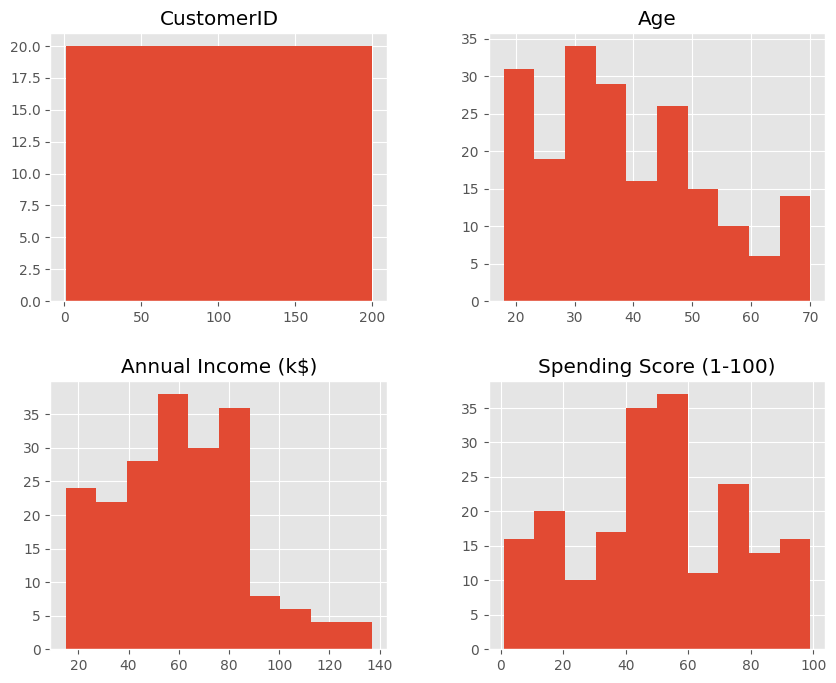

In [9]:
df.hist(figsize=(10,8))
plt.show()

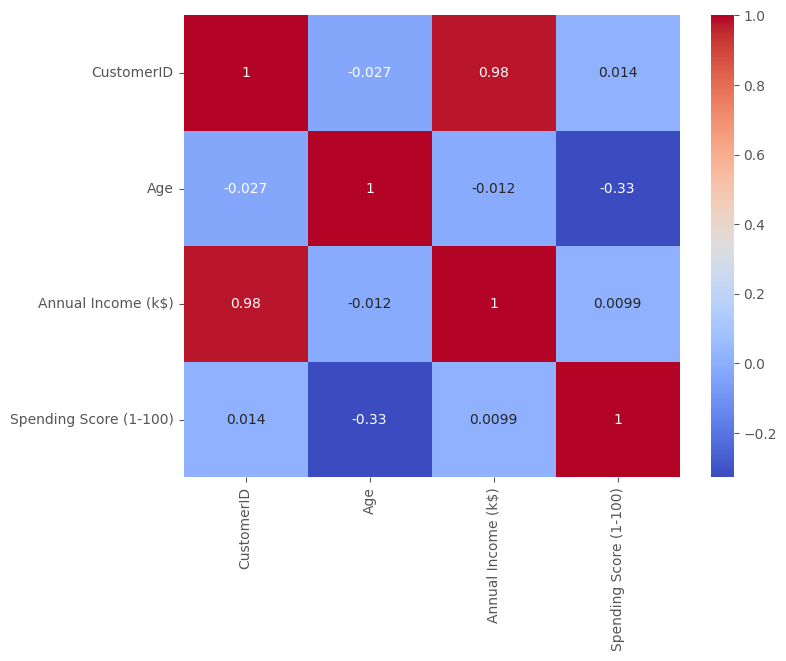

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.show()

In [12]:
X = df[['Annual Income (k$)','Spending Score (1-100)']]

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

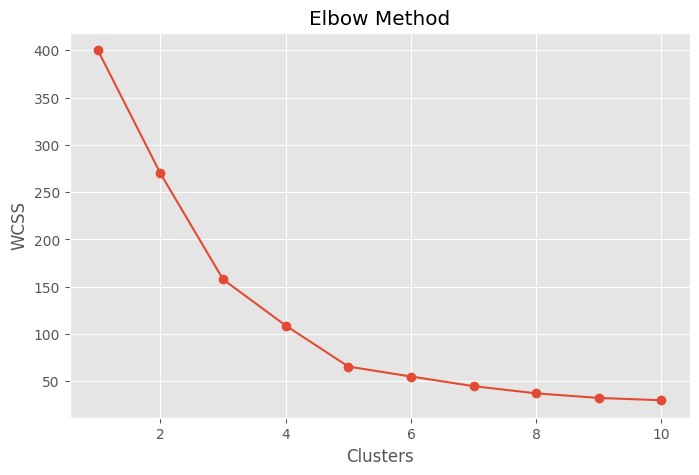

In [14]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(n_clusters=i,
                  random_state=42,
                  n_init=10)

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker="o")

plt.xlabel("Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [15]:
kmeans=KMeans(n_clusters=5,
              random_state=42,
              n_init=10)

df["Cluster"]=kmeans.fit_predict(X_scaled)

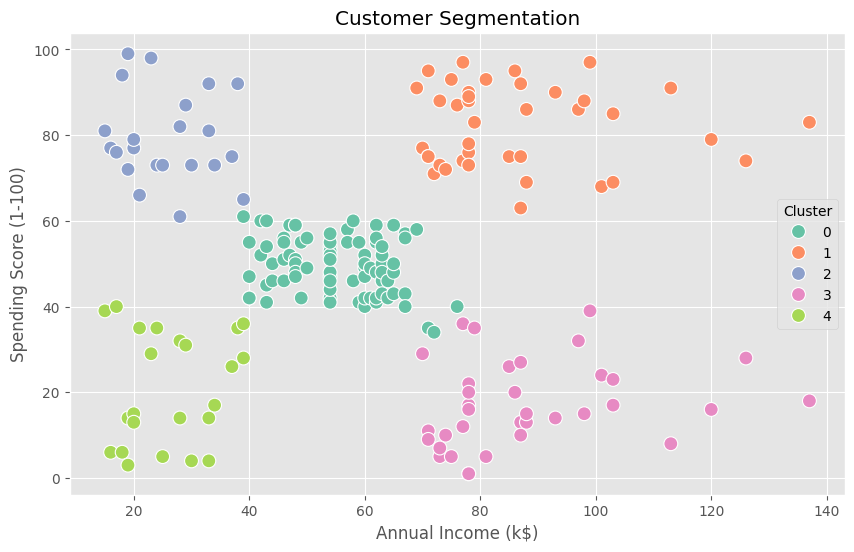

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(data=df,
                x="Annual Income (k$)",
                y="Spending Score (1-100)",
                hue="Cluster",
                palette="Set2",
                s=100)

plt.title("Customer Segmentation")

plt.show()

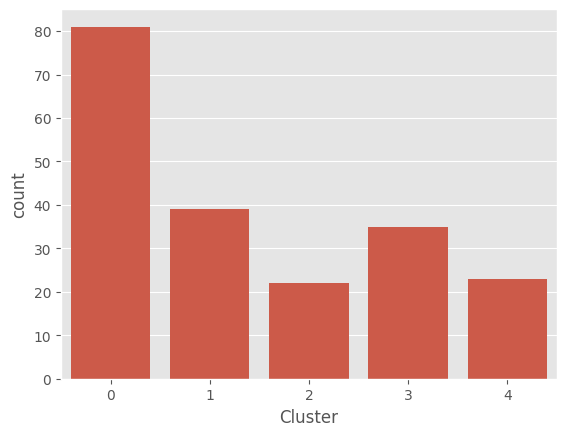

In [17]:
sns.countplot(x="Cluster",data=df)

plt.show()

In [18]:
cluster_profile=df.groupby("Cluster")[["Annual Income (k$)",
                                       "Spending Score (1-100)"]].mean()

cluster_profile

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


# Business Insights

• Cluster 0 contains customers with high spending scores.

• Cluster 1 represents average customers.

• Cluster 2 contains premium customers with high income.

• Cluster 3 includes budget-conscious customers.

• Cluster 4 may require targeted promotional campaigns.


# Conclusion

Customer segmentation using K-Means successfully divided customers into meaningful groups based on Annual Income and Spending Score. Businesses can use these clusters to personalize marketing campaigns, improve customer retention, and optimize promotional offers.